# Prediction Market Simulator — Analysis
SHBI-GB.7301 final project. This notebook reproduces the report's tables and figures from the saved experiment outputs in `results/` (master seed **20260812**, n = 20,000 replications per point).

Regenerate the CSVs first if needed: `python -m src.experiments`.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import plotly.io as pio

pd.set_option('display.float_format', lambda v: f'{v:,.4f}')
RESULTS = Path.cwd().parent / 'results'
tables = {p.stem: pd.read_csv(p) for p in sorted(RESULTS.glob('*.csv'))}
sorted(tables)

['headline_interaction',
 'headline_kappa',
 'model_case_matrix',
 'policy_comparison_variantA',
 'policy_comparison_variantB_kappa03',
 'run_length_control',
 'sweep_cost',
 'sweep_jump_rate',
 'sweep_kappa',
 'sweep_sigma_p']

## 1. Policy comparison at the baseline market
Variant B, κ = 0.3, σ_p = 0.05, σ_q = 0.02, T = 100, no costs. Each row reports the professor's three measures + the 95% CI, and the paired difference vs buy-and-hold on common random numbers (Lecture 7).

In [2]:
comp = tables['policy_comparison_variantB_kappa03']
comp[['policy','mean_profit','ci_low','ci_high','p_loss',
      'mean_loss_given_loss','diff_vs_bh','beats_bh']]

,policy,mean_profit,ci_low,ci_high,p_loss,mean_loss_given_loss,diff_vs_bh,beats_bh
0,"EMA(alpha=0.1, delta=0.02)",0.0372,0.0304,0.0440,0.6019,-0.3605,0.0391,True
1,"EMA(alpha=0.1, delta=0.05)",0.0593,0.0525,0.0662,0.6019,-0.3382,0.0612,True
2,"EMA(alpha=0.1, delta=0.1)",0.1015,0.0949,0.1082,0.5875,-0.2892,0.1034,True
3,"EMA(alpha=0.3, delta=0.02)",0.0313,0.0245,0.0381,0.6019,-0.3664,0.0332,True
4,"EMA(alpha=0.3, delta=0.05)",0.0614,0.0546,0.0682,0.6019,-0.3359,0.0633,True
5,"EMA(alpha=0.3, delta=0.1)",0.0629,0.0580,0.0678,0.3147,-0.2592,0.0648,True
6,"EMA(alpha=0.6, delta=0.02)",0.0366,0.0298,0.0434,0.6019,-0.3611,0.0385,True
7,"EMA(alpha=0.6, delta=0.05)",0.0600,0.0545,0.0655,0.3999,-0.2951,0.0619,True
8,"EMA(alpha=0.6, delta=0.1)",-0.0000,-0.0001,0.0000,0.0001,-0.1803,0.0019,False
9,Buy-and-hold,-0.0019,-0.0087,0.0049,0.6019,-0.3997,0.0000,False


**Reading it:** every EMA cell except (α=0.6, δ=0.10) — which almost never trades — significantly beats buy-and-hold here. The winner is EMA(α=0.1, δ=0.10): slow smoothing plus a wide entry threshold waits for large, persistent dips.

## 2. Headline: how much persistence does an EMA trader need?
Best-cell edge over buy-and-hold per (κ, cost); `any_ema_beats_bh` marks CI-significance of at least one grid cell.

In [3]:
head = tables['headline_kappa']
head[['kappa','cost','best_policy','best_mean_profit','bh_mean_profit',
      'diff_vs_bh','diff_ci_low','diff_ci_high','any_ema_beats_bh']]

,kappa,cost,best_policy,best_mean_profit,bh_mean_profit,diff_vs_bh,diff_ci_low,diff_ci_high,any_ema_beats_bh
0,0.0500,0.0000,"EMA(alpha=0.1, delta=0.1)",0.0850,0.0020,0.0830,0.0815,0.0844,True
1,0.0500,0.0100,"EMA(alpha=0.1, delta=0.1)",0.0750,-0.0080,0.0830,0.0816,0.0845,True
2,0.0500,0.0200,"EMA(alpha=0.3, delta=0.1)",0.0678,-0.0180,0.0858,0.0817,0.0899,True
3,0.1000,0.0000,"EMA(alpha=0.1, delta=0.1)",0.0914,-0.0042,0.0955,0.0942,0.0968,True
4,0.1000,0.0100,"EMA(alpha=0.1, delta=0.1)",0.0814,-0.0142,0.0956,0.0943,0.0969,True
5,0.1000,0.0200,"EMA(alpha=0.1, delta=0.1)",0.0715,-0.0242,0.0957,0.0944,0.0969,True
6,0.2000,0.0000,"EMA(alpha=0.1, delta=0.1)",0.0964,-0.0058,0.1022,0.1009,0.1035,True
7,0.2000,0.0100,"EMA(alpha=0.1, delta=0.1)",0.0866,-0.0158,0.1024,0.1011,0.1037,True
8,0.2000,0.0200,"EMA(alpha=0.1, delta=0.1)",0.0767,-0.0258,0.1025,0.1012,0.1038,True
9,0.3000,0.0000,"EMA(alpha=0.1, delta=0.1)",0.1019,-0.0004,0.1023,0.1007,0.1038,True


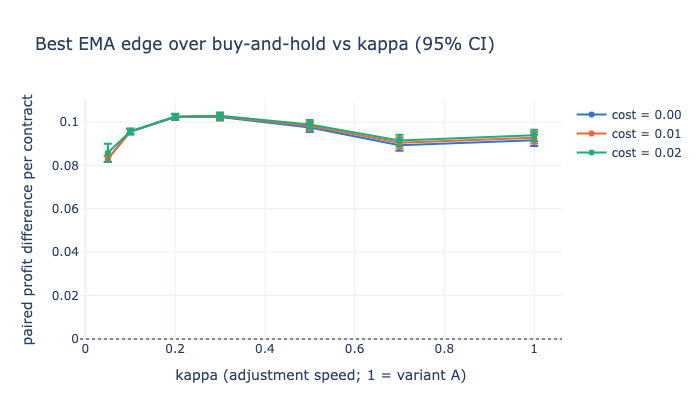

In [4]:
import plotly.graph_objects as go
fig = go.Figure()
for c, color in [(0.0, '#2a78d6'), (0.01, '#eb6834'), (0.02, '#1baf7a')]:
    d = head[head['cost'] == c].sort_values('kappa')
    fig.add_scatter(x=d['kappa'], y=d['diff_vs_bh'], name=f'cost = {c:.2f}',
                    mode='lines+markers', line=dict(color=color, width=2),
                    error_y=dict(type='data',
                                 array=d['diff_ci_high'] - d['diff_vs_bh']))
fig.add_hline(y=0, line=dict(dash='dot', color='#898781'))
fig.update_layout(title='Best EMA edge over buy-and-hold vs kappa (95% CI)',
                  xaxis_title='kappa (adjustment speed; 1 = variant A)',
                  yaxis_title='paired profit difference per contract',
                  template='plotly_white', height=420)
fig.show(renderer='png')

**Answer to the headline question:** at σ_p = 0.05 the market does *not* need any persistence — the best EMA cell beats buy-and-hold at every κ ∈ [0.05, 1], even at a 2¢ per-trade cost. The edge *peaks* at moderate persistence (κ ≈ 0.2–0.3, ≈ +\$0.10 per \$1 contract): slow enough adjustment that dips persist long enough to catch, fast enough that the mispricing still corrects before settlement. At κ = 0.05 the correction is slower than the horizon and the edge shrinks.

## 3. The interaction that actually drives the answer: noise × persistence
The κ×σ_p grid (fixed cost 0.01) shows exploitability is created by observation noise and only *shaped* by persistence — with σ_p = 0 there is nothing to exploit at any κ (zero-noise sweep row), and the edge grows monotonically in σ_p at every κ.

In [5]:
inter = tables['headline_interaction']
pivot = inter.pivot(index='sigma_p', columns='kappa', values='diff_vs_bh')
sig = inter.pivot(index='sigma_p', columns='kappa', values='any_ema_beats_bh')
print('best EMA edge over BH (per contract):')
display(pivot.round(3))
print('CI-significant in every cell:', bool(sig.all().all()))

best EMA edge over BH (per contract):


kappa,0.0500,0.1000,0.2000,0.3000,0.5000,0.7000,1.0000
sigma_p,,,,,,,
0.0100,0.0160,0.0100,0.0110,0.0120,0.0170,0.0080,0.0120
0.0200,0.0370,0.0360,0.0340,0.0300,0.0290,0.0320,0.0330
0.0500,0.0830,0.0970,0.1020,0.1030,0.0970,0.0920,0.0920
0.0800,0.0880,0.1070,0.1240,0.1300,0.1340,0.1360,0.1400


CI-significant in every cell: True


## 4. Sensitivity sweeps and costs

In [6]:
sw = tables['sweep_sigma_p']
ema = sw[sw['alpha'].notna()]
best = ema.loc[ema.groupby('sigma_p')['diff_vs_bh'].idxmax()]
best[['sigma_p','policy','mean_profit','diff_vs_bh','beats_bh']]

,sigma_p,policy,mean_profit,diff_vs_bh,beats_bh
6,0.0000,"EMA(alpha=0.6, delta=0.02)",0.0000,0.0027,False
14,0.0100,"EMA(alpha=0.3, delta=0.02)",0.0090,0.0121,True
28,0.0200,"EMA(alpha=0.6, delta=0.02)",0.0342,0.0331,True
35,0.0500,"EMA(alpha=0.1, delta=0.1)",0.0938,0.0913,True
49,0.0800,"EMA(alpha=0.3, delta=0.1)",0.1386,0.1385,True
63,0.1200,"EMA(alpha=0.6, delta=0.1)",0.2076,0.2061,True


In [7]:
sc = tables['sweep_cost']
ema_c = sc[sc['alpha'].notna()]
best_c = ema_c.loc[ema_c.groupby('cost')['mean_profit'].idxmax()]
bh_c = sc[sc['policy'] == 'Buy-and-hold'][['cost','mean_profit']]
best_c[['cost','policy','mean_profit','p_loss','beats_bh']].merge(
    bh_c, on='cost', suffixes=('_best_ema', '_bh'))

,cost,policy,mean_profit_best_ema,p_loss,beats_bh,mean_profit_bh
0,0.0000,"EMA(alpha=0.1, delta=0.1)",0.0909,0.5416,True,-0.0000
1,0.0100,"EMA(alpha=0.1, delta=0.1)",0.0808,0.5399,True,-0.0102
2,0.0200,"EMA(alpha=0.1, delta=0.1)",0.0704,0.5426,True,-0.0229


## 5. Run-length control (Lecture 3)
Replications needed for a ±0.005 CI half-width on the κ = 0.2 headline cell — the doubling schedule from the course.

In [8]:
tables['run_length_control']

,round,n_total,half_width
0,0,1000,0.0307
1,1,2000,0.0215
2,2,4000,0.0152
3,3,8000,0.0108
4,4,16000,0.0076
5,5,32000,0.0054
6,6,64000,0.0038


## 6. Validation evidence (Section 7)
The same checks the pytest suite asserts, shown numerically.

In [9]:
from src.validation import (martingale_check, calibration_check,
                            seed_reproducibility_check)
m = martingale_check()
print(f"martingale: mean q_T = {m['mean_qT']:.4f} vs q0 = {m['q0']} "
      f"(SE {m['se_qT']:.4f}); settle freq = {m['settle_freq']:.4f} "
      f"(SE {m['se_settle']:.4f})")
print('calibration grid:')
display(pd.DataFrame(calibration_check()))
print('seed check:', seed_reproducibility_check())

martingale: mean q_T = 0.3999 vs q0 = 0.4 (SE 0.0005); settle freq = 0.4032 (SE 0.0035)
calibration grid:


,q0,settle_freq,se
0,0.1000,0.0972,0.0021
1,0.2500,0.2510,0.0031
2,0.5000,0.4987,0.0035
3,0.7500,0.7487,0.0031
4,0.9000,0.8977,0.0021


seed check: {'same_seed_identical': True, 'different_seed_differs': True}


## 7. Extension: the full model-case matrix and the news frontier
Clearly-labelled results **beyond the approved model** (which is the λ = 0 row/case everywhere): variant A/B × Poisson news jumps on/off, then the jump-rate sweep. The approved-model headline results above are untouched by these.

In [10]:
cases = tables['model_case_matrix']
cases[['case','best_policy','best_mean_profit','bh_mean_profit',
       'diff_vs_bh','diff_ci_low','diff_ci_high','best_beats_bh']]

,case,best_policy,best_mean_profit,bh_mean_profit,diff_vs_bh,diff_ci_low,diff_ci_high,best_beats_bh
0,Variant A · no jumps,"EMA(alpha=0.1, delta=0.1)",0.0842,-0.0096,0.0938,0.0912,0.0964,True
1,Variant B (kappa=0.3) · no jumps,"EMA(alpha=0.1, delta=0.1)",0.0967,-0.0057,0.1024,0.1008,0.1040,True
2,Variant A · jumps,"EMA(alpha=0.6, delta=0.05)",0.0661,-0.0097,0.0757,0.0731,0.0783,True
3,Variant B (kappa=0.3) · jumps,"EMA(alpha=0.1, delta=0.1)",0.0677,-0.0101,0.0778,0.0758,0.0798,True


In [11]:
js = tables['sweep_jump_rate']
js = js.assign(erosion_vs_lambda0=1 - js['diff_vs_bh'] / js['diff_vs_bh'].iloc[0])
js[['jump_rate','best_policy','diff_vs_bh','diff_ci_low','diff_ci_high',
    'erosion_vs_lambda0','any_ema_beats_bh']]

,jump_rate,best_policy,diff_vs_bh,diff_ci_low,diff_ci_high,erosion_vs_lambda0,any_ema_beats_bh
0,0.0000,"EMA(alpha=0.1, delta=0.1)",0.1029,0.1014,0.1045,0.0000,True
1,0.0200,"EMA(alpha=0.1, delta=0.1)",0.0928,0.0910,0.0945,0.0985,True
2,0.0500,"EMA(alpha=0.1, delta=0.1)",0.0786,0.0765,0.0807,0.2361,True
3,0.1000,"EMA(alpha=0.1, delta=0.1)",0.0643,0.0620,0.0666,0.3750,True
4,0.2000,"EMA(alpha=0.1, delta=0.1)",0.0387,0.0360,0.0414,0.6243,True


**Reading it:** the edge survives in all four model worlds at λ = 0.05 but news is expensive — the paired edge decays roughly linearly in λ (−24% at one event per 20 periods, −62% at one per 5). Under variant A with jumps the winning cell shifts from slow (α=0.1) to fast (α=0.6) smoothing: when the truth can jump, a long-memory EMA compares prices against a stale anchor. Mechanism figure: `report/figures/fig_jump_path.png`.

## 8. Real-data calibration (scope: inputs only)
Bundled Polymarket samples and their implied model parameters — evidence that the simulator defaults (σ_q ≈ 0.02 per step) are realistic. We do not fit or backtest on real data.

In [12]:
from src.calibration import list_samples, load_sample, estimate_params
rows = []
for name in list_samples():
    md_ = load_sample(name)
    est = estimate_params(md_.prices)
    rows.append({'market': md_.question[:60], 'n_obs': est['n_obs'],
                 'q0': est['q0'], 'sigma_q_hat': est['sigma_q'],
                 'sigma_p_hat': est['sigma_p']})
pd.DataFrame(rows)

,market,n_obs,q0,sigma_q_hat,sigma_p_hat
0,Strait of Hormuz traffic returns to normal by ...,742,0.1750,0.0177,0.0016
1,Will Adanech Abiebie be the next Prime Ministe...,703,0.0100,0.0088,0.0003
2,Will Josh Stein win the 2028 Democratic presid...,418,0.0100,0.0033,0.0000
3,Will NVIDIA be the largest company in the worl...,743,0.6550,0.0191,0.0000
4,Will the Republicans win the Arkansas Senate r...,708,0.9475,0.0022,0.0000
